In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data import data, returns, portfolio, pnl

In [43]:
!pip install scipy

                                              0.0/36.6 MB ? eta -:--:--
                                              0.1/36.6 MB 4.2 MB/s eta 0:00:09
                                              0.2/36.6 MB 2.5 MB/s eta 0:00:15
                                              0.3/36.6 MB 2.7 MB/s eta 0:00:14
                                              0.4/36.6 MB 2.4 MB/s eta 0:00:15
                                              0.6/36.6 MB 2.7 MB/s eta 0:00:14
                                              0.7/36.6 MB 2.8 MB/s eta 0:00:13
                                              0.8/36.6 MB 2.6 MB/s eta 0:00:14
                                              0.9/36.6 MB 2.5 MB/s eta 0:00:15
     -                                        1.1/36.6 MB 2.6 MB/s eta 0:00:14
     -                                        1.2/36.6 MB 2.6 MB/s eta 0:00:14
     -                                        1.2/36.6 MB 2.6 MB/s eta 0:00:14
     -                                        1.2/36.6 MB 2


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
Total_portfolio_amount = portfolio.sum()

In [29]:
weights = portfolio.values / Total_portfolio_amount
weights

array([0.25, 0.25, 0.5 ])

In [20]:
covariance_matrix = returns.cov()
covariance_matrix

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS
Ticker,,,
RELIANCE.NS,0.000152,0.000087,0.000076
ADANIENT.NS,0.000087,0.000376,0.000105
LT.NS,0.000076,0.000105,0.000182


In [34]:
portfolio_variance = weights.T @ covariance_matrix @ weights
portfolio_variance

np.float64(0.00013464871678938752)

In [35]:
portfolio_volatility = np.sqrt(portfolio_variance)
portfolio_volatility

np.float64(0.011603823369449724)

In [39]:
mean_returns = returns.mean()
mean_returns

Ticker
RELIANCE.NS    0.001106
ADANIENT.NS   -0.000342
LT.NS          0.000561
dtype: float64

In [40]:
portfolio_mean_return = weights @ mean_returns
portfolio_mean_return

np.float64(0.0004715675430225172)

In [46]:
from scipy.stats import norm
confidence_intervals = [90,95,99]
z_scores = []
for confidence_level in confidence_intervals:
    z_scores.append(norm.ppf(confidence_level / 100))
z_scores

[np.float64(1.2815515655446004),
 np.float64(1.6448536269514722),
 np.float64(2.3263478740408408)]

In [48]:
parametric_VaR = []
for z_score in z_scores:
    parametric_VaR.append((z_score*portfolio_volatility - portfolio_mean_return)*Total_portfolio_amount)
parametric_VaR

[np.float64(2879.866092479759),
 np.float64(3723.0046825442223),
 np.float64(5304.592456648454)]

In [51]:
%store -r VaR
VaR

{90: np.float64(2379.298223949438),
 95: np.float64(3154.7405097301707),
 99: np.float64(5391.558674985572)}

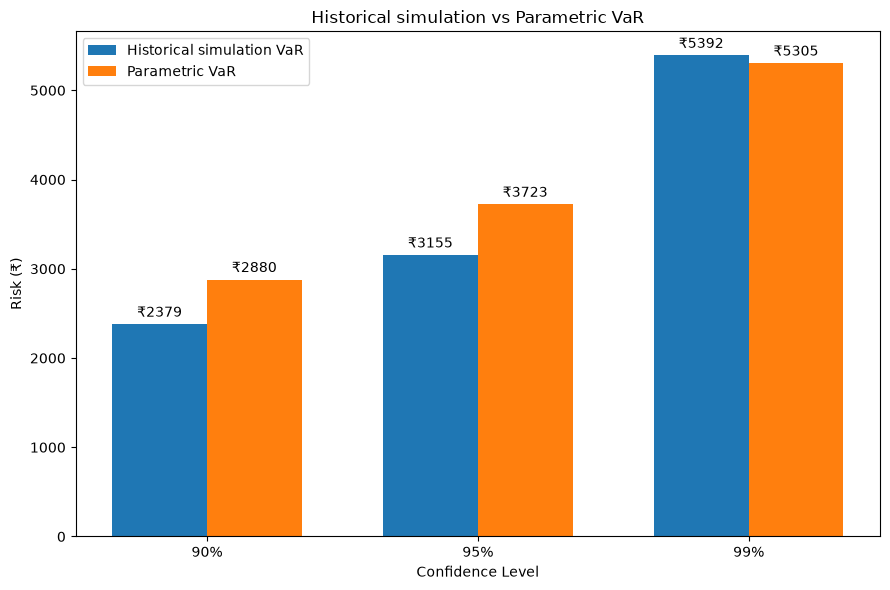

In [55]:
x = np.arange(len(confidence_intervals))
width = 0.35

plt.figure(figsize=(9, 6))

bars1 = plt.bar(x - width/2, VaR.values(), width, label="Historical simulation VaR")
bars2 = plt.bar(x + width/2, parametric_VaR, width, label="Parametric VaR")

plt.xticks(x, ["90%", "95%", "99%"])
plt.xlabel("Confidence Level")
plt.ylabel("Risk (₹)")
plt.title("Historical simulation vs Parametric VaR")
plt.legend()

plt.bar_label(bars1, fmt="₹%.0f", padding=3)
plt.bar_label(bars2, fmt="₹%.0f", padding=3)

plt.tight_layout()
plt.show()